# AirSense — Exploratory Data Analysis (EDA)

Notebook ini digunakan untuk mengeksplorasi karakteristik dan pola temporal data kualitas udara AirSense sebelum masuk ke tahap perhitungan ISPU, historical analytics, dan forecasting.

### Tujuan
1. Menganalisis distribusi setiap parameter kualitas udara.
2. Mengamati perubahan parameter terhadap waktu.
3. Mengidentifikasi pola berdasarkan jam.
4. Mengidentifikasi waktu terjadinya konsentrasi tertinggi (peak time).
5. Menganalisis hubungan antarpolutan.
6. Menganalisis hubungan suhu dan kelembapan dengan konsentrasi polutan.

> **Catatan:** Analisis pada tahap pengembangan menggunakan data dummy untuk membangun dan memvalidasi pipeline. Hasilnya belum merepresentasikan kondisi kualitas udara sebenarnya.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Library berhasil di-import.")

Library berhasil di-import.


## 1. Load dan Persiapan Dataset

Dataset konsentrasi gas dimuat dan timestamp dikonversi ke format datetime agar dapat digunakan untuk analisis berbasis waktu.

In [2]:
DATA_PATH = Path("../../dummy_data/output/dummy_tb_konsentrasi_gas.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce",
    utc=True
)

df = df.sort_values("created_at").reset_index(drop=True)

print(f"Jumlah observasi : {len(df):,}")
print(f"Periode awal     : {df['created_at'].min()}")
print(f"Periode akhir    : {df['created_at'].max()}")

df.head()

Jumlah observasi : 10,081
Periode awal     : 2026-08-30 13:49:00+00:00
Periode akhir    : 2026-09-06 13:49:00+00:00


,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
0,2026-08-30 13:49:00+00:00,11.31,14.87,2682.45,0.42,20.61,38.99,48.40
1,2026-08-30 13:50:00+00:00,16.18,21.71,2673.63,0.00,73.92,36.95,52.98
2,2026-08-30 13:51:00+00:00,15.33,17.59,2818.74,0.00,21.04,37.30,52.37
3,2026-08-30 13:52:00+00:00,13.20,9.97,2548.78,0.43,21.05,38.50,49.88
4,2026-08-30 13:53:00+00:00,16.70,17.53,2537.62,0.00,80.64,38.24,53.81


In [3]:
#Definisikan Parameter
pollutant_cols = [
    "pm25_ugm3",
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "o3_ugm3"
]

environment_cols = [
    "temperature",
    "humidity"
]

numeric_cols = pollutant_cols + environment_cols

print("Polutan     :", pollutant_cols)
print("Lingkungan :", environment_cols)

Polutan     : ['pm25_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'o3_ugm3']
Lingkungan : ['temperature', 'humidity']


## 2. Analisis Distribusi Parameter

Analisis distribusi dilakukan untuk memahami karakteristik awal setiap parameter, seperti pusat data, penyebaran, kemencengan distribusi, serta keberadaan nilai yang jauh dari mayoritas observasi.

Karena dataset yang digunakan masih berupa data dummy, pola yang ditemukan pada tahap ini digunakan untuk menguji proses analisis dan tidak diinterpretasikan sebagai kondisi kualitas udara sebenarnya.

In [4]:
distribution_summary = df[numeric_cols].describe().T

distribution_summary["median"] = df[numeric_cols].median()
distribution_summary["skewness"] = df[numeric_cols].skew()

distribution_summary[
    ["count", "mean", "median", "std", "min", "25%", "75%", "max", "skewness"]
]

,count,mean,median,std,min,25%,75%,max,skewness
pm25_ugm3,10081.00,15.89,15.27,6.44,8.00,13.26,17.31,84.23,5.90
pm10_ugm3,10081.00,18.20,17.50,7.48,7.50,14.57,20.47,99.77,4.81
co_ugm3,10081.00,2950.41,2873.32,417.22,2192.88,2691.62,3160.60,7308.76,4.02
no2_ugm3,10081.00,0.78,0.00,11.26,0.00,0.00,0.06,242.03,18.18
o3_ugm3,10081.00,26.37,20.35,14.79,19.63,19.67,21.01,88.85,2.42
temperature,10081.00,34.96,34.69,2.01,29.83,33.33,36.62,40.89,0.25
humidity,10081.00,60.95,61.26,6.04,39.77,56.54,65.39,78.40,-0.16


Kolom skewness berguna untuk melihat apakah distribusinya simetris atau cenderung memiliki ekor panjang ke salah satu sisi.

### 2.1 Distribusi Polutan

Histogram digunakan untuk melihat bentuk distribusi konsentrasi masing-masing polutan. Visualisasi dibuat secara terpisah karena setiap parameter memiliki rentang nilai yang berbeda.

In [5]:
def plot_distribution(data, column, title, xlabel):
    plt.figure(figsize=(8, 4))

    plt.hist(
        data[column].dropna(),
        bins=40,
        edgecolor="black",
        alpha=0.8
    )

    plt.axvline(
        data[column].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {data[column].mean():.2f}"
    )

    plt.axvline(
        data[column].median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {data[column].median():.2f}"
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.tight_layout()
    plt.show()

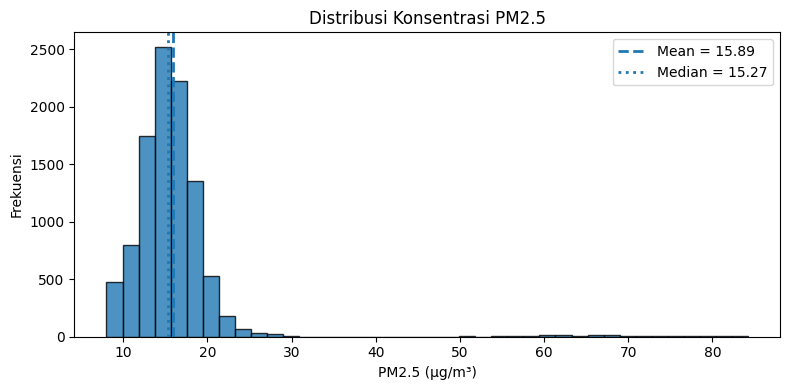

In [6]:
#PM2.5
plot_distribution(
    df,
    "pm25_ugm3",
    "Distribusi Konsentrasi PM2.5",
    "PM2.5 (µg/m³)"
)

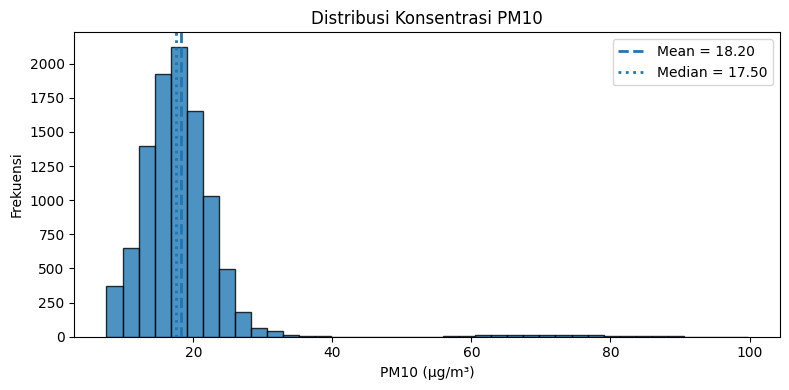

In [7]:
#PM10
plot_distribution(
    df,
    "pm10_ugm3",
    "Distribusi Konsentrasi PM10",
    "PM10 (µg/m³)"
)

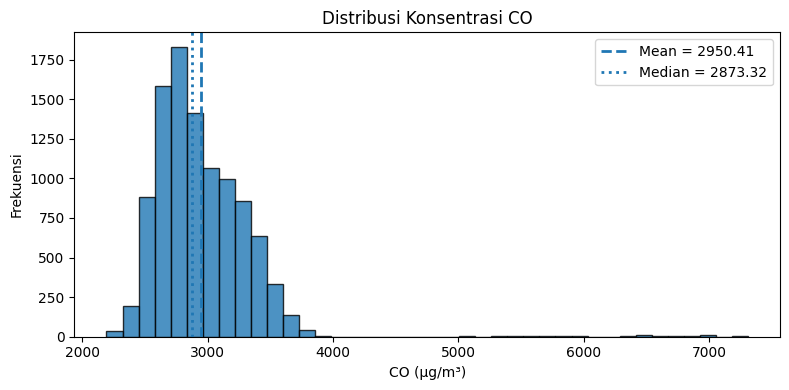

In [8]:
#CO
plot_distribution(
    df,
    "co_ugm3",
    "Distribusi Konsentrasi CO",
    "CO (µg/m³)"
)

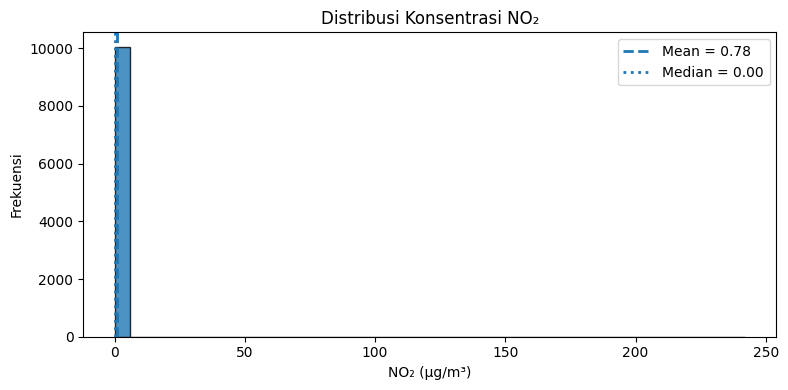

In [9]:
#NO2
plot_distribution(
    df,
    "no2_ugm3",
    "Distribusi Konsentrasi NO₂",
    "NO₂ (µg/m³)"
)

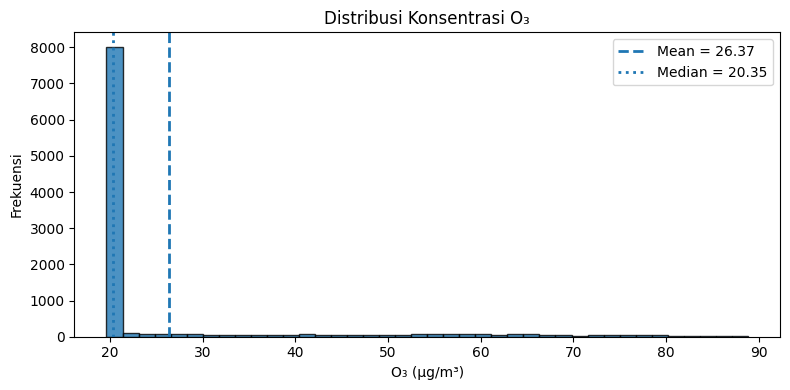

In [10]:
#O3
plot_distribution(
    df,
    "o3_ugm3",
    "Distribusi Konsentrasi O₃",
    "O₃ (µg/m³)"
)

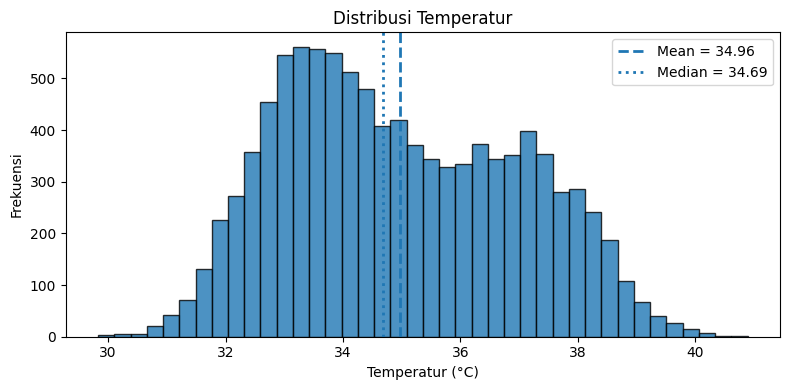

In [ ]:
#Temperature
plot_distribution(
    df,
    "temperature",
    "Distribusi Temperatur",
    "Temperatur (°C)"
)

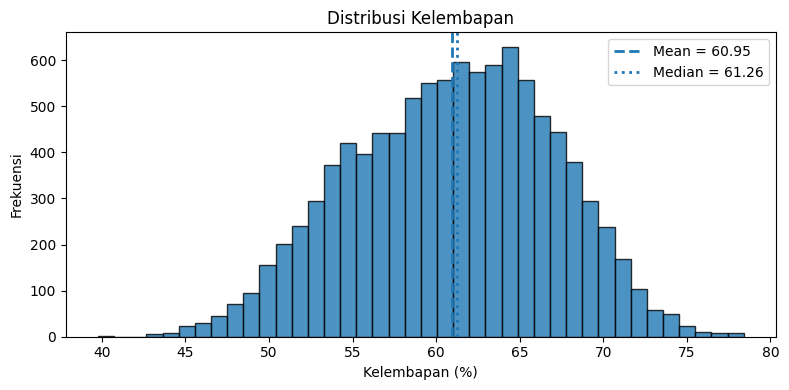

In [12]:
#Kelembapan
plot_distribution(
    df,
    "humidity",
    "Distribusi Kelembapan",
    "Kelembapan (%)"
)

### Interpretasi Distribusi

Hasil eksplorasi menunjukkan bahwa karakteristik distribusi berbeda pada setiap parameter. PM2.5, PM10, dan CO memiliki konsentrasi utama pada rentang tertentu dengan sejumlah observasi bernilai tinggi, sehingga distribusinya cenderung memiliki ekor ke kanan.

NO₂ menunjukkan distribusi yang sangat terkonsentrasi pada nilai rendah, dengan sebagian besar observasi bernilai nol dan sejumlah kecil observasi memiliki nilai yang jauh lebih tinggi. O₃ juga menunjukkan konsentrasi observasi yang tinggi pada rentang sekitar 20 µg/m³ disertai sejumlah observasi dengan konsentrasi yang lebih tinggi.

Sementara itu, temperatur dan kelembapan memiliki distribusi yang relatif lebih menyebar dibandingkan NO₂ dan O₃.

Karakteristik distribusi tersebut menunjukkan bahwa nilai ekstrem tidak dapat langsung dianggap sebagai kesalahan data. Analisis berbasis waktu diperlukan untuk mengetahui apakah nilai tinggi muncul secara acak atau membentuk pola tertentu.

Karena data yang digunakan merupakan data dummy, hasil ini digunakan untuk mengevaluasi pipeline analisis dan belum merepresentasikan kondisi kualitas udara sebenarnya.

## 3. Historical Time-Series Analysis

Analisis time-series dilakukan untuk melihat perubahan parameter kualitas udara sepanjang periode pengamatan. Data satu menit diagregasi menjadi rata-rata per jam untuk menghasilkan visualisasi tren yang lebih mudah dibaca tanpa mengubah data mentah.

In [13]:
df_hourly = (
    df.set_index("created_at")[numeric_cols]
      .resample("1h")
      .mean()
      .reset_index()
)

print("Data 1 menit :", len(df))
print("Data per jam :", len(df_hourly))

df_hourly.head()

Data 1 menit : 10081
Data per jam : 169


,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
0,2026-08-30 13:00:00+00:00,15.03,18.05,2647.84,0.11,48.91,38.22,51.92
1,2026-08-30 14:00:00+00:00,15.32,17.60,2691.98,0.12,46.88,37.71,53.96
2,2026-08-30 15:00:00+00:00,14.81,17.25,2682.58,0.12,36.39,37.62,54.35
3,2026-08-30 16:00:00+00:00,15.10,17.37,2781.92,0.11,31.15,36.77,56.50
4,2026-08-30 17:00:00+00:00,15.74,17.82,2934.52,0.15,26.36,36.20,57.74


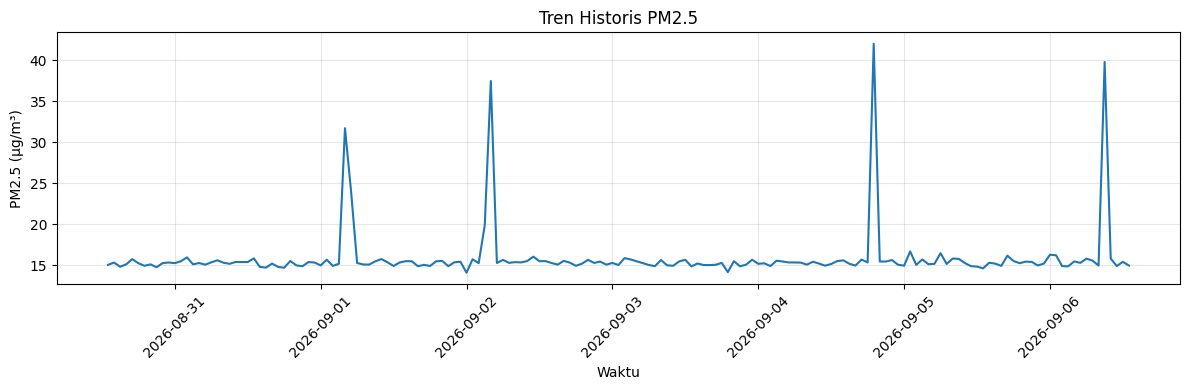

In [14]:
#Plot PM2.5
plt.figure(figsize=(12, 4))

plt.plot(
    df_hourly["created_at"],
    df_hourly["pm25_ugm3"]
)

plt.title("Tren Historis PM2.5")
plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

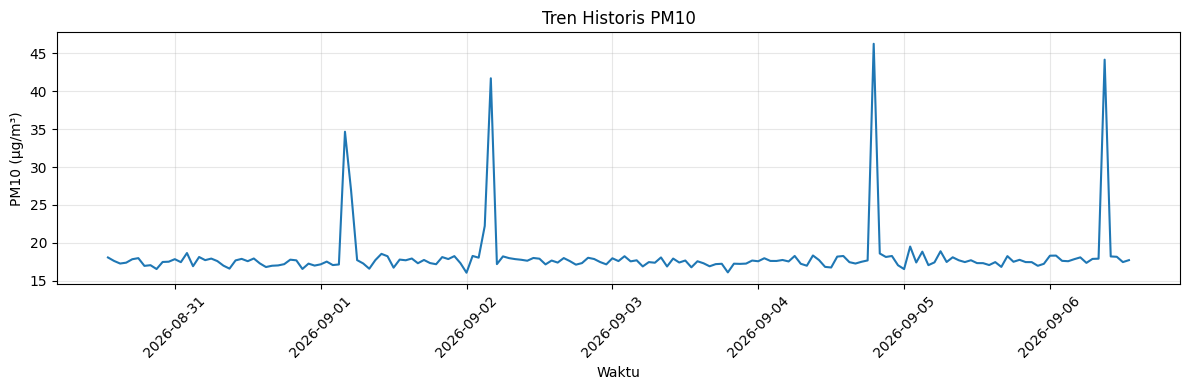

In [15]:
#Plot PM10
plt.figure(figsize=(12, 4))

plt.plot(
    df_hourly["created_at"],
    df_hourly["pm10_ugm3"]
)

plt.title("Tren Historis PM10")
plt.xlabel("Waktu")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

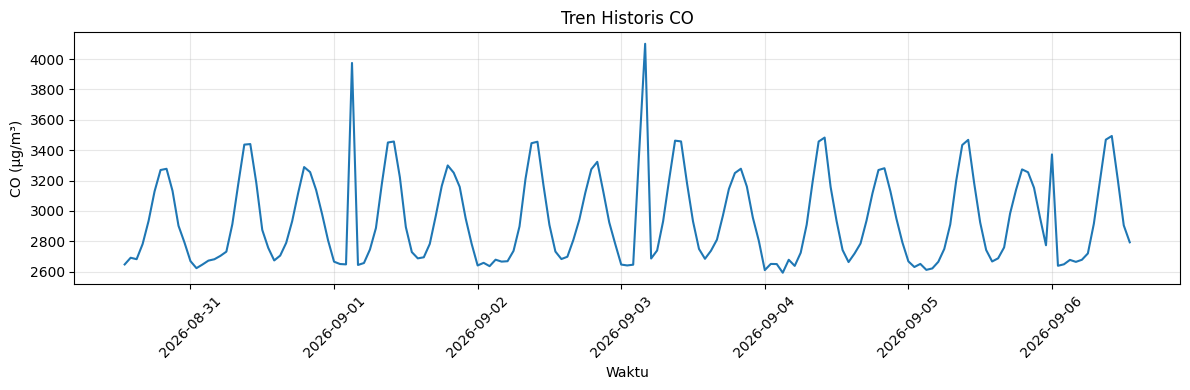

In [16]:
#Plot CO
plt.figure(figsize=(12, 4))

plt.plot(
    df_hourly["created_at"],
    df_hourly["co_ugm3"]
)

plt.title("Tren Historis CO")
plt.xlabel("Waktu")
plt.ylabel("CO (µg/m³)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

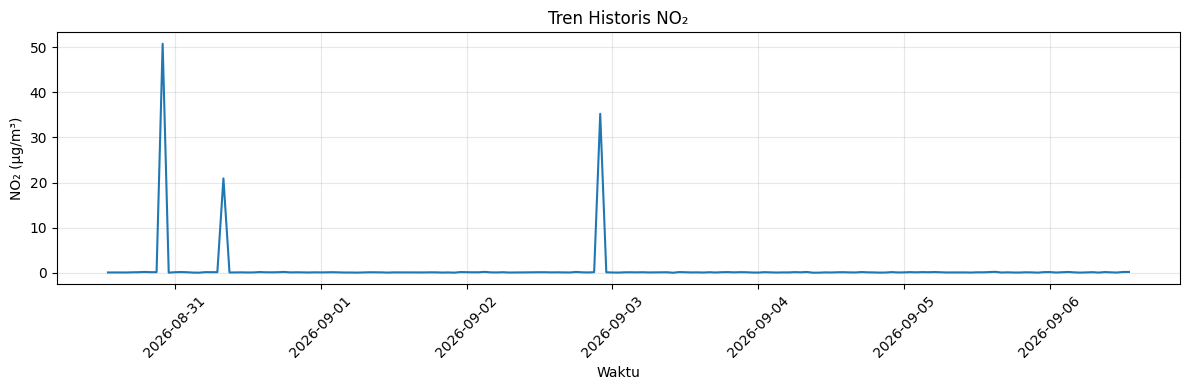

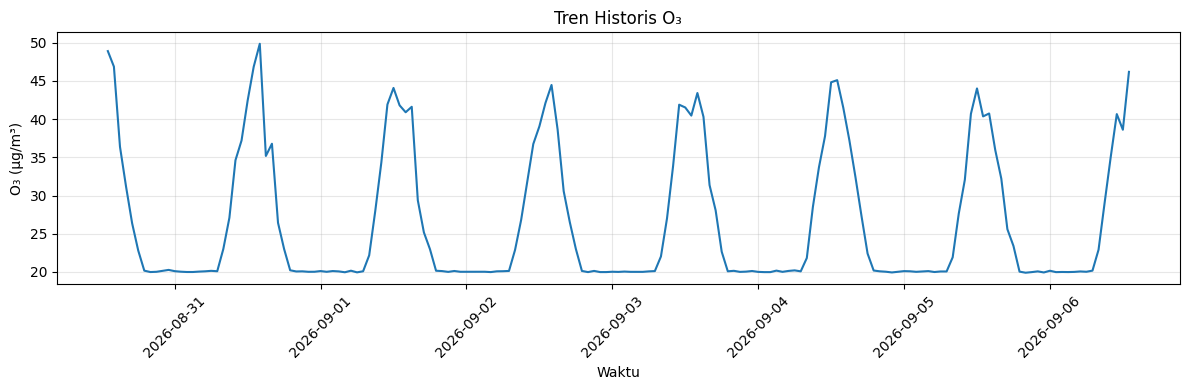

In [17]:
#NO2 & O3
for col, title, ylabel in [
    ("no2_ugm3", "Tren Historis NO₂", "NO₂ (µg/m³)"),
    ("o3_ugm3", "Tren Historis O₃", "O₃ (µg/m³)")
]:
    plt.figure(figsize=(12, 4))
    plt.plot(df_hourly["created_at"], df_hourly[col])
    plt.title(title)
    plt.xlabel("Waktu")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

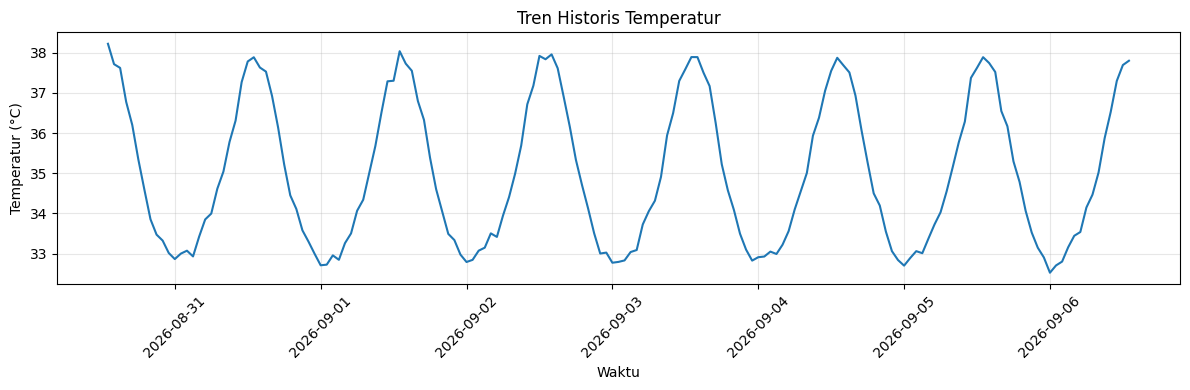

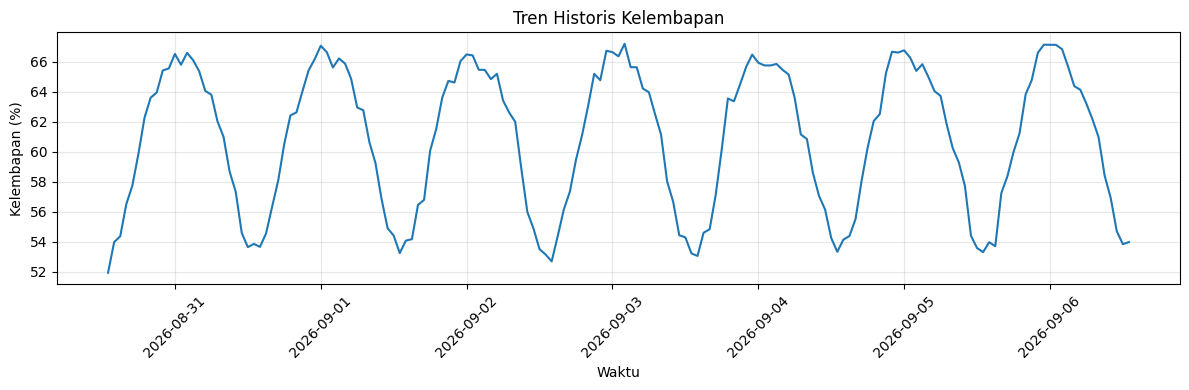

In [ ]:
#Temperature & Kelembapan
for col, title, ylabel in [
    ("temperature", "Tren Historis Temperatur", "Temperatur (°C)"),
    ("humidity", "Tren Historis Kelembapan", "Kelembapan (%)")
]:
    plt.figure(figsize=(12, 4))
    plt.plot(df_hourly["created_at"], df_hourly[col])
    plt.title(title)
    plt.xlabel("Waktu")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Interpretasi Historical Time-Series

Visualisasi time-series menunjukkan karakteristik temporal yang berbeda pada setiap parameter. PM2.5 dan PM10 relatif stabil pada sebagian besar periode, tetapi memiliki beberapa lonjakan pada waktu tertentu yang terlihat terjadi pada periode yang berdekatan.

CO dan O₃ menunjukkan pola perubahan yang berulang secara harian. Pola periodik juga terlihat pada temperatur dan kelembapan, dengan kecenderungan perubahan yang berlawanan antara kedua parameter lingkungan tersebut.

NO₂ memiliki karakteristik yang berbeda karena sebagian besar observasi berada pada konsentrasi rendah dan hanya menunjukkan beberapa lonjakan pada periode tertentu.

Pola temporal ini menunjukkan bahwa informasi waktu berpotensi relevan untuk analisis lanjutan dan pengembangan fitur forecasting. Namun, karena dataset yang digunakan merupakan data dummy, pola tersebut belum dapat diinterpretasikan sebagai pola kualitas udara sebenarnya.

In [20]:
#Untuk konteks proyek AirSense di Jawa, konversikan ke WIB terlebih dahulu:
df["created_at_local"] = (
    df["created_at"]
    .dt.tz_convert("Asia/Jakarta")
)

df[["created_at", "created_at_local"]].head()

,created_at,created_at_local
0,2026-08-30 13:49:00+00:00,2026-08-30 20:49:00+07:00
1,2026-08-30 13:50:00+00:00,2026-08-30 20:50:00+07:00
2,2026-08-30 13:51:00+00:00,2026-08-30 20:51:00+07:00
3,2026-08-30 13:52:00+00:00,2026-08-30 20:52:00+07:00
4,2026-08-30 13:53:00+00:00,2026-08-30 20:53:00+07:00


## 4. Hourly Pattern Analysis

Analisis pola per jam dilakukan untuk mengetahui perubahan rata-rata parameter berdasarkan waktu dalam satu hari. Timestamp dikonversi dari UTC ke waktu lokal (WIB/Asia Jakarta) agar interpretasi jam sesuai dengan konteks penggunaan AirSense.

In [21]:
df["hour"] = df["created_at_local"].dt.hour

hourly_pattern = (
    df.groupby("hour")[numeric_cols]
      .mean()
)

hourly_pattern.head()

,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
hour,,,,,,,
0,15.39,17.57,2952.44,0.14,26.50,36.19,57.64
1,15.12,17.42,3133.31,0.17,22.89,35.29,60.05
2,18.93,21.32,3275.17,0.15,20.14,34.60,62.02
3,15.37,17.73,3274.82,0.13,20.04,34.07,63.23
4,15.07,17.36,3142.89,0.14,20.04,33.52,64.63


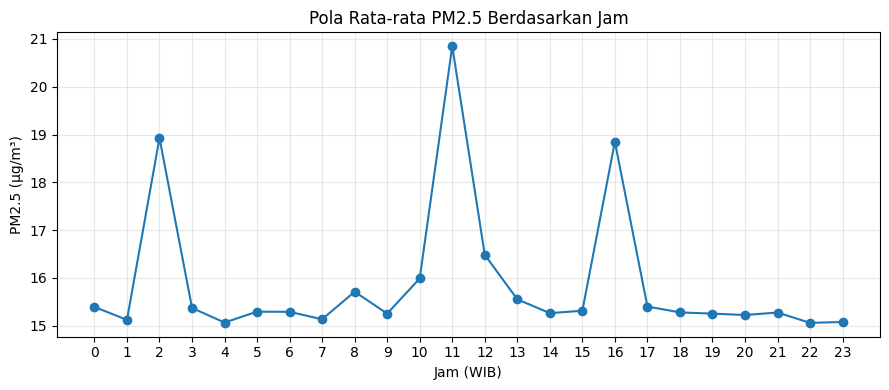

In [22]:
#PM2.5
plt.figure(figsize=(9, 4))

plt.plot(
    hourly_pattern.index,
    hourly_pattern["pm25_ugm3"],
    marker="o"
)

plt.title("Pola Rata-rata PM2.5 Berdasarkan Jam")
plt.xlabel("Jam (WIB)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

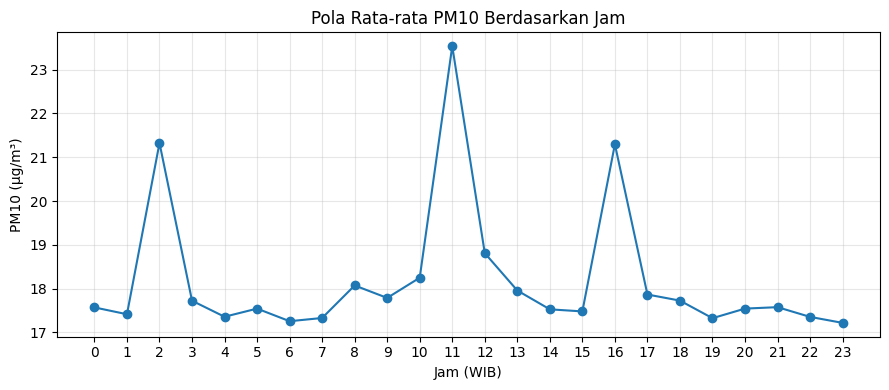

In [23]:
#PM10
plt.figure(figsize=(9, 4))

plt.plot(
    hourly_pattern.index,
    hourly_pattern["pm10_ugm3"],
    marker="o"
)

plt.title("Pola Rata-rata PM10 Berdasarkan Jam")
plt.xlabel("Jam (WIB)")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

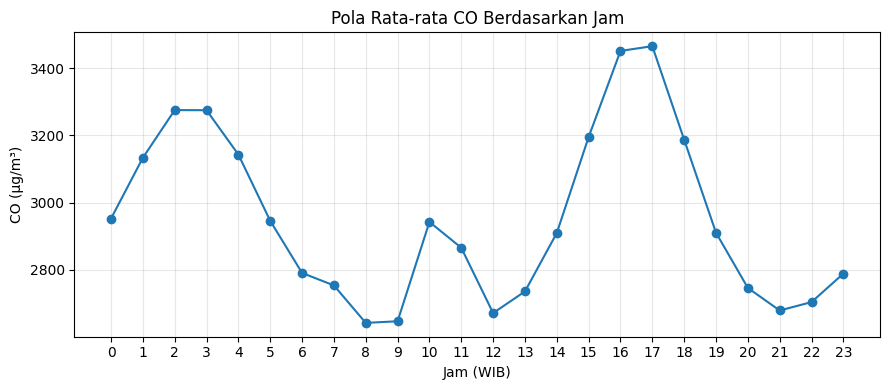

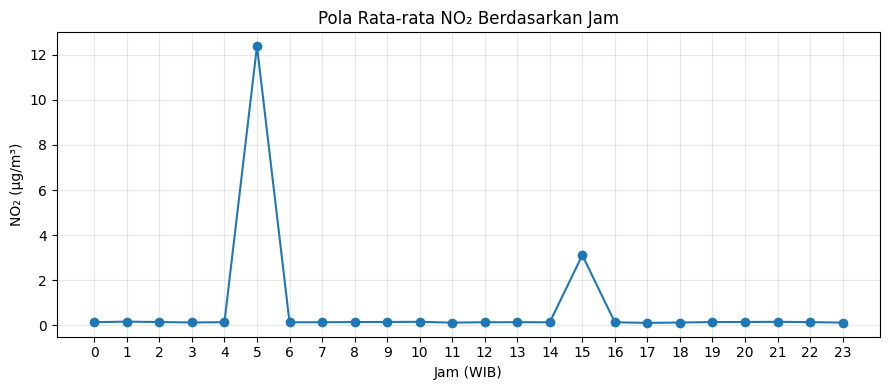

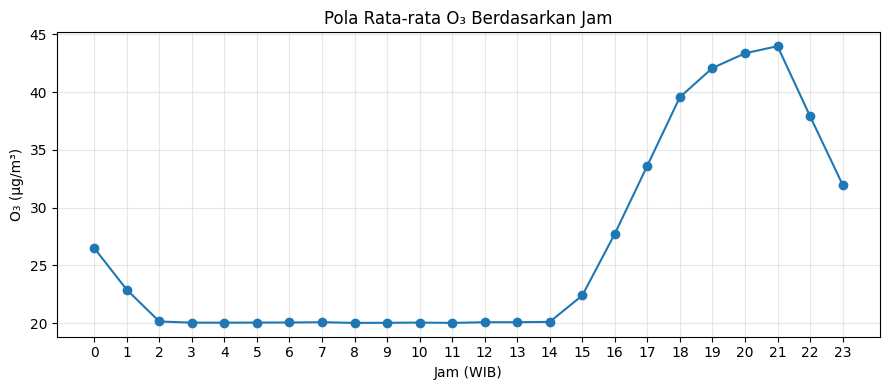

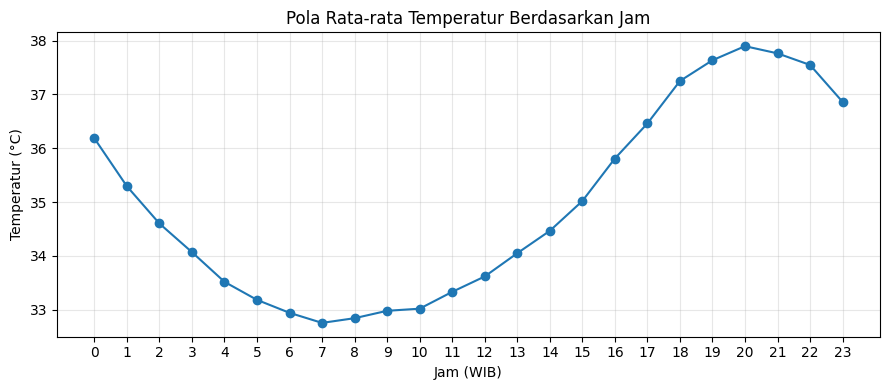

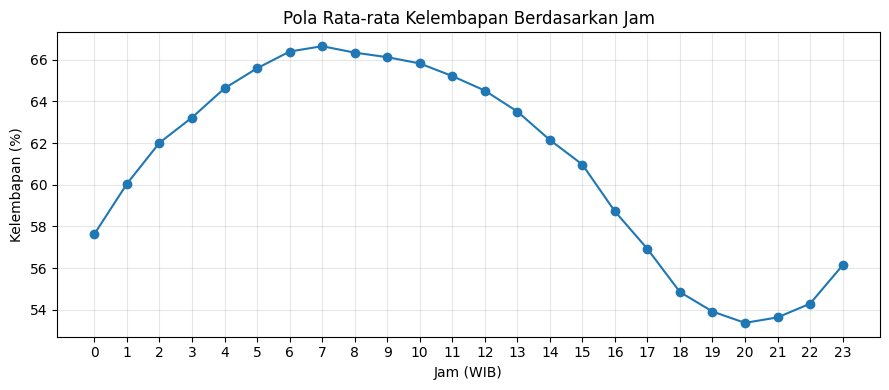

In [24]:
plot_config = [
    ("co_ugm3", "CO", "CO (µg/m³)"),
    ("no2_ugm3", "NO₂", "NO₂ (µg/m³)"),
    ("o3_ugm3", "O₃", "O₃ (µg/m³)"),
    ("temperature", "Temperatur", "Temperatur (°C)"),
    ("humidity", "Kelembapan", "Kelembapan (%)")
]

for col, name, ylabel in plot_config:
    plt.figure(figsize=(9, 4))

    plt.plot(
        hourly_pattern.index,
        hourly_pattern[col],
        marker="o"
    )

    plt.title(f"Pola Rata-rata {name} Berdasarkan Jam")
    plt.xlabel("Jam (WIB)")
    plt.ylabel(ylabel)
    plt.xticks(range(0, 24))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
#Hitung Peak Time
peak_summary = []

for col in numeric_cols:
    peak_hour = hourly_pattern[col].idxmax()
    peak_value = hourly_pattern[col].max()

    lowest_hour = hourly_pattern[col].idxmin()
    lowest_value = hourly_pattern[col].min()

    peak_summary.append({
        "Parameter": col,
        "Jam Tertinggi (WIB)": peak_hour,
        "Rata-rata Tertinggi": round(peak_value, 2),
        "Jam Terendah (WIB)": lowest_hour,
        "Rata-rata Terendah": round(lowest_value, 2)
    })

peak_summary = pd.DataFrame(peak_summary)
peak_summary

,Parameter,Jam Tertinggi (WIB),Rata-rata Tertinggi,Jam Terendah (WIB),Rata-rata Terendah
0,pm25_ugm3,11,20.85,22,15.06
1,pm10_ugm3,11,23.54,23,17.22
2,co_ugm3,17,3465.31,8,2642.22
3,no2_ugm3,5,12.37,17,0.11
4,o3_ugm3,21,43.97,11,20.02
5,temperature,20,37.90,7,32.76
6,humidity,7,66.65,20,53.38


### Interpretasi Hourly Pattern dan Peak Time

Analisis berdasarkan jam menunjukkan adanya perbedaan pola temporal pada setiap parameter. PM2.5 dan PM10 memiliki pola yang relatif stabil pada sebagian besar jam, tetapi menunjukkan peningkatan rata-rata pada beberapa jam tertentu. Keduanya mencapai rata-rata tertinggi pada pukul 11.00 WIB.

CO menunjukkan pola perubahan harian yang lebih jelas dan mencapai rata-rata tertinggi pada pukul 17.00 WIB. O₃ juga menunjukkan pola temporal yang kuat, dengan konsentrasi rata-rata meningkat pada sore hingga malam hari dan mencapai nilai tertinggi pada pukul 21.00 WIB.

NO₂ memiliki pola yang berbeda karena sebagian besar nilainya sangat rendah. Peningkatan rata-rata yang terlihat pada pukul 05.00 dan 15.00 WIB kemungkinan dipengaruhi oleh sejumlah kecil nilai tinggi sehingga perlu dianalisis lebih lanjut sebelum dianggap sebagai pola harian yang konsisten.

Temperatur mencapai rata-rata tertinggi pada pukul 20.00 WIB, sedangkan kelembapan mencapai rata-rata tertinggi pada pukul 07.00 WIB. Secara visual, temperatur dan kelembapan menunjukkan kecenderungan pola yang berlawanan.

Hasil ini menunjukkan bahwa fitur berbasis waktu, seperti jam pengamatan, berpotensi dipertimbangkan pada tahap feature engineering. Namun, karena data yang digunakan merupakan data dummy selama tujuh hari, pola yang ditemukan belum dapat digeneralisasikan sebagai kondisi lingkungan sebenarnya.

### 4.1 Konsistensi Peak Time Antarhari

Analisis peak time per hari dilakukan untuk mengetahui apakah jam dengan konsentrasi tinggi muncul secara konsisten atau hanya dipengaruhi oleh kejadian tertentu pada satu hari.

In [26]:
#Buat tanggal lokal dari timestamp WIB
df["date_local"] = df["created_at_local"].dt.date

daily_hourly = (
    df.groupby(["date_local", "hour"])[numeric_cols]
      .mean()
      .reset_index()
)

daily_hourly.head()

,date_local,hour,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
0,2026-08-30,20,15.03,18.05,2647.84,0.11,48.91,38.22,51.92
1,2026-08-30,21,15.32,17.60,2691.98,0.12,46.88,37.71,53.96
2,2026-08-30,22,14.81,17.25,2682.58,0.12,36.39,37.62,54.35
3,2026-08-30,23,15.10,17.37,2781.92,0.11,31.15,36.77,56.50
4,2026-08-31,0,15.74,17.82,2934.52,0.15,26.36,36.20,57.74


In [28]:
#Mencari jam dengan rata-rata tertinggi pada setiap ahri
daily_peak_records = []

for col in pollutant_cols:
    idx = daily_hourly.groupby("date_local")[col].idxmax()

    temp = daily_hourly.loc[
        idx,
        ["date_local", "hour", col]
    ].copy()

    temp["Parameter"] = col
    temp = temp.rename(columns={
        "hour": "Peak Hour",
        col: "Peak Value"
    })

    daily_peak_records.append(temp)

daily_peaks = pd.concat(
    daily_peak_records,
    ignore_index=True
)

daily_peaks.head(15)

,date_local,Peak Hour,Peak Value,Parameter
0,2026-08-30,21,15.32,pm25_ugm3
1,2026-08-31,9,15.95,pm25_ugm3
2,2026-09-01,11,31.71,pm25_ugm3
3,2026-09-02,11,37.47,pm25_ugm3
4,2026-09-03,9,15.86,pm25_ugm3
5,2026-09-04,6,15.66,pm25_ugm3
6,2026-09-05,2,42.02,pm25_ugm3
7,2026-09-06,16,39.80,pm25_ugm3
8,2026-08-30,20,18.05,pm10_ugm3
9,2026-08-31,9,18.64,pm10_ugm3


In [29]:
#Ringkas untuk mengetahui seberapa sering setiap jam menjadi peak
peak_frequency = (
    daily_peaks
    .groupby(["Parameter", "Peak Hour"])
    .size()
    .reset_index(name="Jumlah Hari")
    .sort_values(
        ["Parameter", "Jumlah Hari"],
        ascending=[True, False]
    )
)

peak_frequency

,Parameter,Peak Hour,Jumlah Hari
2,co_ugm3,17,5
0,co_ugm3,10,1
1,co_ugm3,11,1
3,co_ugm3,23,1
5,no2_ugm3,5,2
4,no2_ugm3,1,1
6,no2_ugm3,10,1
7,no2_ugm3,15,1
8,no2_ugm3,20,1
9,no2_ugm3,21,1


## 5. Multi-Pollutant dan Environmental Relationship Analysis

Analisis korelasi digunakan untuk mengeksplorasi hubungan statistik antarpolutan serta hubungan parameter lingkungan dengan konsentrasi polutan. Korelasi digunakan sebagai indikator hubungan, bukan sebagai bukti hubungan sebab-akibat.

In [30]:
#Menghitung Pearson Correlation
correlation_matrix = df[numeric_cols].corr(method="pearson")

correlation_matrix.round(2)

,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
pm25_ugm3,1.00,0.93,0.01,-0.01,-0.02,-0.04,0.03
pm10_ugm3,0.93,1.00,0.00,-0.01,-0.02,-0.04,0.03
co_ugm3,0.01,0.00,1.00,0.01,-0.02,0.06,-0.06
no2_ugm3,-0.01,-0.01,0.01,1.00,-0.02,-0.04,0.03
o3_ugm3,-0.02,-0.02,-0.02,-0.02,1.00,0.49,-0.43
temperature,-0.04,-0.04,0.06,-0.04,0.49,1.00,-0.87
humidity,0.03,0.03,-0.06,0.03,-0.43,-0.87,1.00


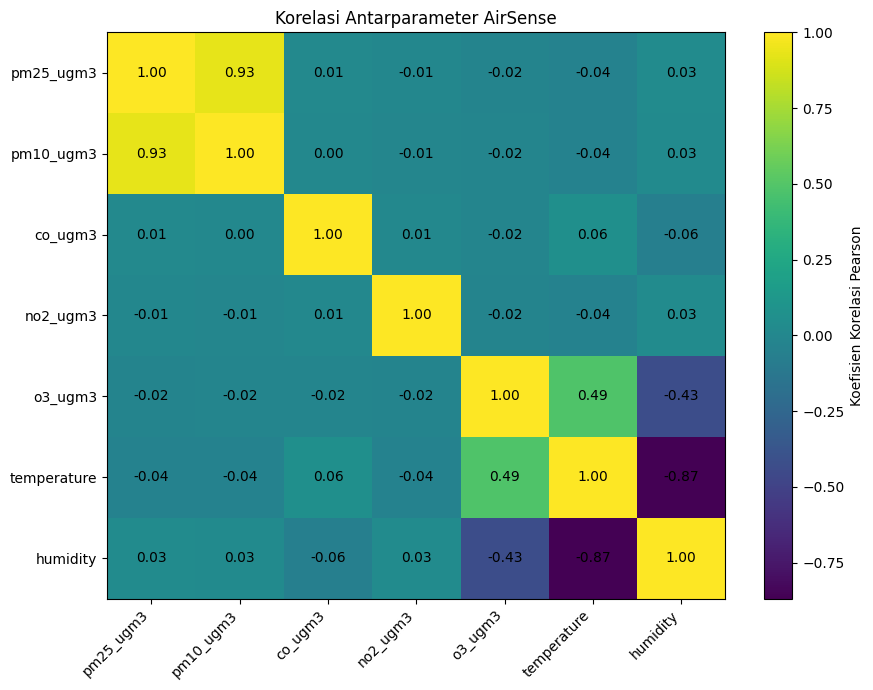

In [31]:
#Visualisasi sebagai Heatmap
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))

ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im, label="Koefisien Korelasi Pearson")
plt.title("Korelasi Antarparameter AirSense")
plt.tight_layout()
plt.show()

### Interpretasi Korelasi

Hasil analisis korelasi menunjukkan bahwa PM2.5 dan PM10 memiliki hubungan positif yang sangat kuat dengan koefisien Pearson sebesar 0,93. Pola ini konsisten dengan visualisasi time-series sebelumnya, ketika perubahan kedua parameter terlihat sering terjadi pada periode yang berdekatan.

Temperatur dan kelembapan memiliki korelasi negatif yang kuat sebesar -0,87, yang menunjukkan bahwa pada dataset ini peningkatan temperatur cenderung diikuti oleh penurunan kelembapan.

O₃ memiliki korelasi positif sedang dengan temperatur sebesar 0,49 dan korelasi negatif sedang dengan kelembapan sebesar -0,43. Sementara itu, CO dan NO₂ menunjukkan korelasi linear yang relatif rendah terhadap sebagian besar parameter lainnya.

Korelasi menunjukkan hubungan statistik antarvariabel dan tidak dapat digunakan secara langsung untuk menyimpulkan hubungan sebab-akibat. Selain itu, karena dataset yang digunakan merupakan data dummy, hubungan yang ditemukan pada tahap ini belum dapat dianggap sebagai karakteristik kondisi lingkungan sebenarnya.

## 6. Temporal / Lag Analysis

Analisis temporal dilakukan untuk mengukur hubungan antara nilai suatu parameter pada waktu saat ini dengan nilainya pada beberapa interval sebelumnya. Analisis ini digunakan sebagai dasar awal dalam menentukan fitur lag yang berpotensi digunakan pada forecasting kualitas udara 60 menit ke depan.

Lag yang dianalisis adalah 1, 10, 30, dan 60 menit. Korelasi lag yang tinggi menunjukkan adanya keterkaitan temporal, tetapi tidak secara langsung menjamin bahwa lag tersebut akan meningkatkan performa model forecasting.

In [32]:
#Hitung Autocoreelation
lags = [1, 10, 30, 60]

autocorr_results = []

for col in pollutant_cols:
    for lag in lags:
        corr = df[col].corr(df[col].shift(lag))

        autocorr_results.append({
            "Parameter": col,
            "Lag (menit)": lag,
            "Autocorrelation": corr
        })

autocorr_df = pd.DataFrame(autocorr_results)

autocorr_df

,Parameter,Lag (menit),Autocorrelation
0,pm25_ugm3,1,0.72
1,pm25_ugm3,10,0.50
2,pm25_ugm3,30,0.02
3,pm25_ugm3,60,-0.00
4,pm10_ugm3,1,0.63
5,pm10_ugm3,10,0.44
6,pm10_ugm3,30,0.01
7,pm10_ugm3,60,-0.00
8,co_ugm3,1,0.85
9,co_ugm3,10,0.58


In [ ]:
#Tabel lebih mudah dibaca
autocorr_pivot = autocorr_df.pivot(
    index="Parameter",
    columns="Lag (menit)",
    values="Autocorrelation"
)

autocorr_pivot = autocorr_pivot.round(3)

autocorr_pivot

Lag (menit),1,10,30,60
Parameter,,,,
co_ugm3,0.85,0.58,0.32,0.37
no2_ugm3,0.92,0.14,-0.00,-0.00
o3_ugm3,0.32,0.35,0.34,0.31
pm10_ugm3,0.63,0.44,0.01,-0.00
pm25_ugm3,0.72,0.50,0.02,-0.00


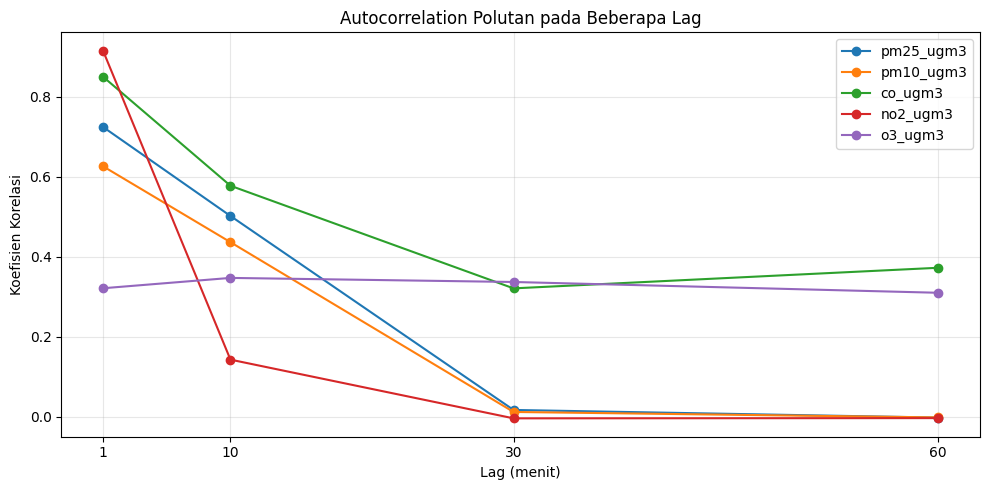

In [34]:
#Visualisasi Autocorrelation
plt.figure(figsize=(10, 5))

for col in pollutant_cols:
    temp = autocorr_df[
        autocorr_df["Parameter"] == col
    ]

    plt.plot(
        temp["Lag (menit)"],
        temp["Autocorrelation"],
        marker="o",
        label=col
    )

plt.title("Autocorrelation Polutan pada Beberapa Lag")
plt.xlabel("Lag (menit)")
plt.ylabel("Koefisien Korelasi")
plt.xticks(lags)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1 Hubungan Fitur Saat Ini dengan Target 60 Menit ke Depan

Karena AirSense dirancang untuk menghasilkan forecasting 60 menit ke depan, dilakukan eksplorasi hubungan antara kondisi pada waktu saat ini (t) dengan konsentrasi polutan pada t+60 menit.

Tahap ini bertujuan untuk memberikan dasar awal bagi feature engineering dan bukan untuk menentukan model akhir.

In [35]:
#Target Sementara
forecast_horizon = 60

for col in pollutant_cols:
    df[f"{col}_target_t60"] = df[col].shift(-forecast_horizon)

target_cols = [
    f"{col}_target_t60"
    for col in pollutant_cols
]

df[
    ["created_at"] +
    pollutant_cols +
    target_cols
].head()

,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,pm25_ugm3_target_t60,pm10_ugm3_target_t60,co_ugm3_target_t60,no2_ugm3_target_t60,o3_ugm3_target_t60
0,2026-08-30 13:49:00+00:00,11.31,14.87,2682.45,0.42,20.61,16.51,21.92,2712.87,0.00,20.20
1,2026-08-30 13:50:00+00:00,16.18,21.71,2673.63,0.00,73.92,16.58,16.74,2809.67,0.00,56.30
2,2026-08-30 13:51:00+00:00,15.33,17.59,2818.74,0.00,21.04,15.39,16.08,2590.17,0.31,20.47
3,2026-08-30 13:52:00+00:00,13.20,9.97,2548.78,0.43,21.05,12.58,13.73,2646.51,0.00,70.18
4,2026-08-30 13:53:00+00:00,16.70,17.53,2537.62,0.00,80.64,16.57,20.75,2638.78,0.00,62.58


In [36]:
#Korelasi Current Value vs t+60
t60_results = []

for col in pollutant_cols:
    target_col = f"{col}_target_t60"

    corr = df[col].corr(df[target_col])

    t60_results.append({
        "Parameter": col,
        "Correlation t vs t+60": corr
    })

t60_correlation = pd.DataFrame(t60_results)

t60_correlation["Correlation t vs t+60"] = (
    t60_correlation["Correlation t vs t+60"]
    .round(3)
)

t60_correlation

,Parameter,Correlation t vs t+60
0,pm25_ugm3,-0.00
1,pm10_ugm3,-0.00
2,co_ugm3,0.37
3,no2_ugm3,-0.00
4,o3_ugm3,0.31


## 7. Preliminary Persistence Baseline

Persistence baseline digunakan sebagai pembanding awal dengan asumsi bahwa nilai parameter 60 menit ke depan sama dengan nilai pada waktu saat ini. Baseline ini belum merupakan model forecasting akhir, tetapi digunakan sebagai referensi untuk mengevaluasi apakah model machine learning nantinya memberikan peningkatan performa.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_results = []

for col in pollutant_cols:
    actual = df[f"{col}_target_t60"]
    predicted = df[col]

    valid = actual.notna() & predicted.notna()

    mae = mean_absolute_error(
        actual[valid],
        predicted[valid]
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual[valid],
            predicted[valid]
        )
    )

    baseline_results.append({
        "Parameter": col,
        "MAE Persistence": mae,
        "RMSE Persistence": rmse
    })

baseline_df = pd.DataFrame(baseline_results)

baseline_df[
    ["MAE Persistence", "RMSE Persistence"]
] = baseline_df[
    ["MAE Persistence", "RMSE Persistence"]
].round(3)

baseline_df

,Parameter,MAE Persistence,RMSE Persistence
0,pm25_ugm3,4.66,9.14
1,pm10_ugm3,6.13,10.60
2,co_ugm3,244.12,468.11
3,no2_ugm3,1.51,16.00
4,o3_ugm3,8.25,17.16


### Interpretasi Temporal

Hasil autocorrelation menunjukkan bahwa setiap polutan memiliki karakteristik temporal yang berbeda. PM2.5 dan PM10 memiliki hubungan temporal yang cukup kuat pada lag pendek, tetapi korelasinya menurun hingga mendekati nol pada lag 30 dan 60 menit.

CO menunjukkan persistensi temporal yang lebih panjang dengan autocorrelation sebesar 0,37 pada lag 60 menit. O₃ memiliki autocorrelation yang relatif stabil pada beberapa lag yang diuji, yaitu sekitar 0,31–0,35.

NO₂ memiliki autocorrelation sangat tinggi pada lag 1 menit, tetapi menurun secara tajam pada lag yang lebih panjang. Hal ini konsisten dengan karakter distribusi NO₂ yang didominasi nilai rendah atau nol dan diselingi sejumlah spike.

Hubungan antara nilai saat ini dan target t+60 juga menunjukkan bahwa nilai saat ini saja belum cukup untuk forecasting seluruh polutan. Oleh karena itu, pengembangan model selanjutnya perlu mengevaluasi kombinasi fitur lag, rolling statistics, parameter lingkungan, dan fitur berbasis waktu melalui validasi time-series.

## 8. Kesimpulan Exploratory Data Analysis

Berdasarkan EDA terhadap dataset dummy AirSense, diperoleh beberapa temuan utama:

- PM2.5 dan PM10 memiliki pola distribusi dan perubahan temporal yang serupa serta menunjukkan korelasi positif yang kuat sebesar 0,93.
- PM2.5 dan PM10 memiliki ketergantungan temporal pada lag pendek, tetapi hubungan tersebut menurun pada lag yang lebih panjang.
- CO menunjukkan pola harian yang cukup jelas dan memiliki persistensi temporal hingga lag 60 menit.
- NO₂ didominasi oleh nilai nol dan memiliki sejumlah spike, sehingga memerlukan perlakuan khusus pada tahap analisis dan pemodelan.
- O₃ menunjukkan pola temporal yang cukup konsisten serta memiliki hubungan sedang dengan temperatur dan kelembapan pada dataset ini.
- Temperatur dan kelembapan menunjukkan pola harian yang berlawanan dan memiliki korelasi negatif yang kuat sebesar -0,87.
- Analisis peak time menunjukkan bahwa beberapa parameter memiliki pola waktu yang lebih konsisten dibandingkan parameter lainnya.
- Nilai saat ini saja belum cukup untuk menghasilkan forecasting t+60 yang baik pada seluruh parameter.
- Fitur lag, rolling statistics, parameter lingkungan, dan fitur berbasis waktu akan dipertimbangkan sebagai kandidat pada tahap feature engineering.
- Persistence baseline telah dihitung sebagai benchmark awal untuk evaluasi model forecasting selanjutnya.

Seluruh temuan pada tahap ini berasal dari data dummy dan digunakan untuk pengembangan serta validasi pipeline. Kesimpulan mengenai kondisi kualitas udara sebenarnya harus dilakukan menggunakan data riil dari perangkat IoT.